In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [8]:
train_df = pd.read_csv('../data/train.csv')
print(f"Dataset Shape: {train_df.shape}")
print(f"Missing Values: {train_df.isnull().sum().sum()}")
train_df.head()

Dataset Shape: (50120, 55)
Missing Values: 0


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


# Target Variable Distribution (Class Imbalance)

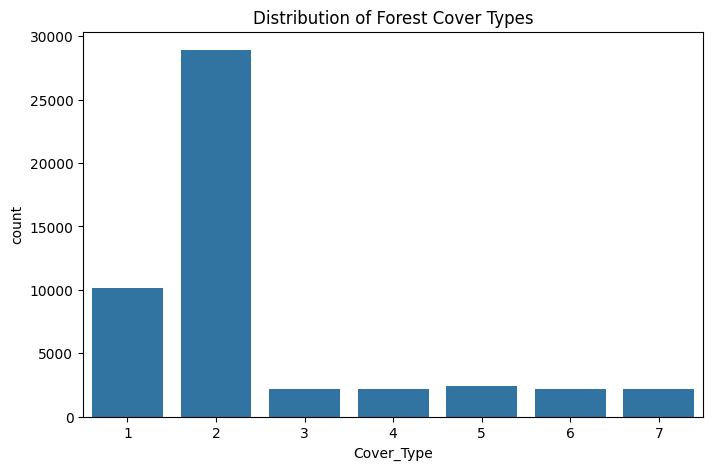

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='Cover_Type')
plt.title('Distribution of Forest Cover Types')
plt.show()

# Feature Distributions & The "Scaling" Justification

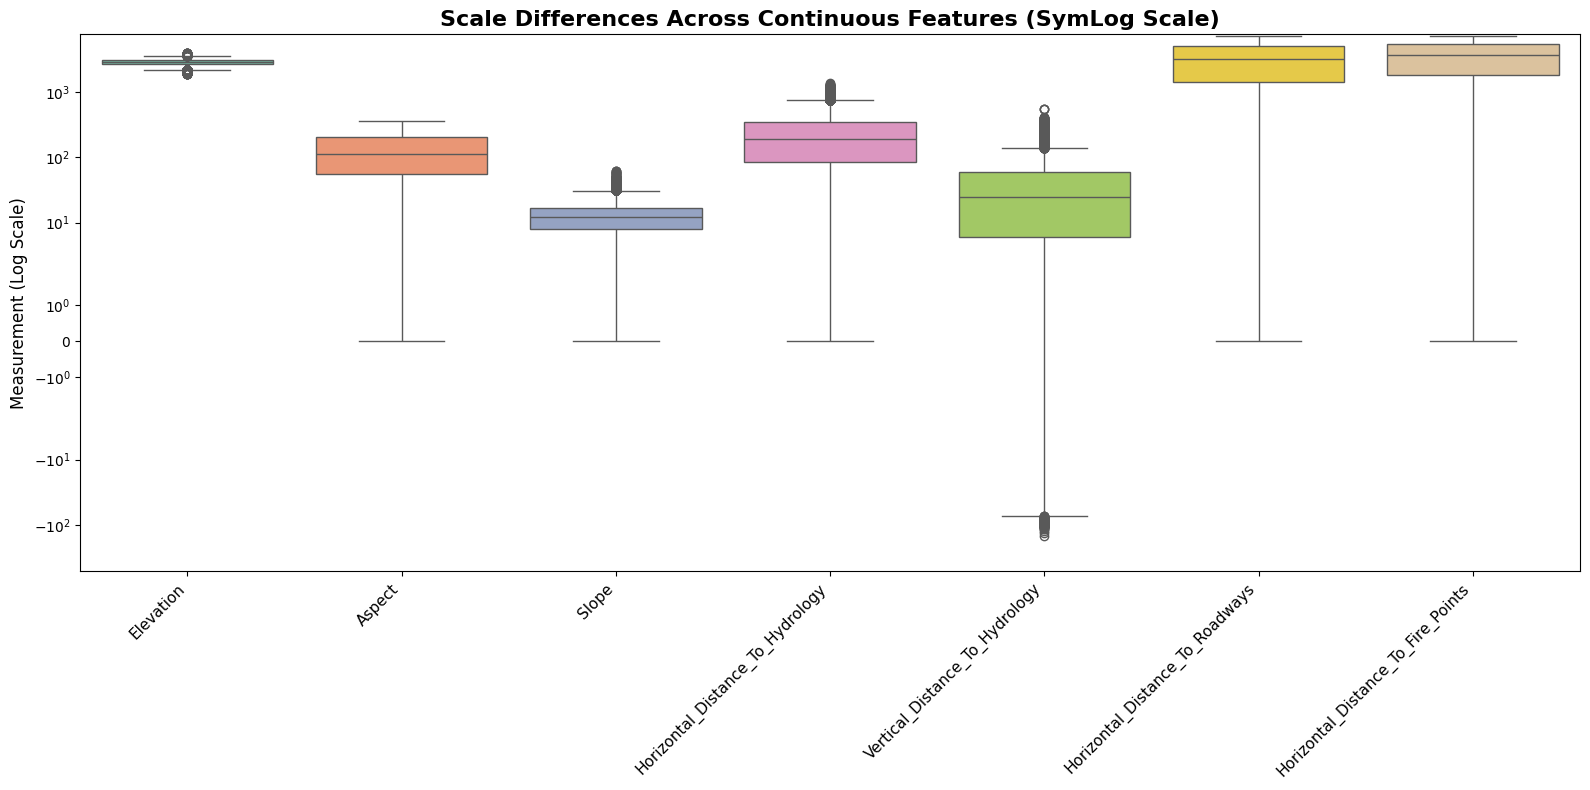

In [10]:
continuous_features = [
    'Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 
    'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 
    'Horizontal_Distance_To_Fire_Points'
]

plt.figure(figsize=(16, 8))
sns.boxplot(data=train_df[continuous_features], palette='Set2')
plt.yscale('symlog') 
plt.xticks(rotation=45, ha='right', fontsize=11) 
plt.title('Scale Differences Across Continuous Features (SymLog Scale)', fontsize=16, fontweight='bold')
plt.ylabel('Measurement (Log Scale)', fontsize=12)
plt.tight_layout() 
plt.show()

# Feature Engineering

In [6]:
# 1. Direct Distance to Hydrology (Pythagorean theorem)
train_df['Direct_Distance_To_Hydrology'] = np.sqrt(
    (train_df['Horizontal_Distance_To_Hydrology'] ** 2) + 
    (train_df['Vertical_Distance_To_Hydrology'] ** 2)
)

train_df['Fire_Road_Dist_Diff'] = (
    train_df['Horizontal_Distance_To_Fire_Points'] - 
    train_df['Horizontal_Distance_To_Roadways']
)

train_df['Mean_Dist_To_Features'] = (
    train_df['Horizontal_Distance_To_Hydrology'] + 
    train_df['Horizontal_Distance_To_Roadways'] + 
    train_df['Horizontal_Distance_To_Fire_Points']
) / 3

print("Successfully engineered 3 new features.")

Successfully engineered 3 new features.


# Correlation Analysis

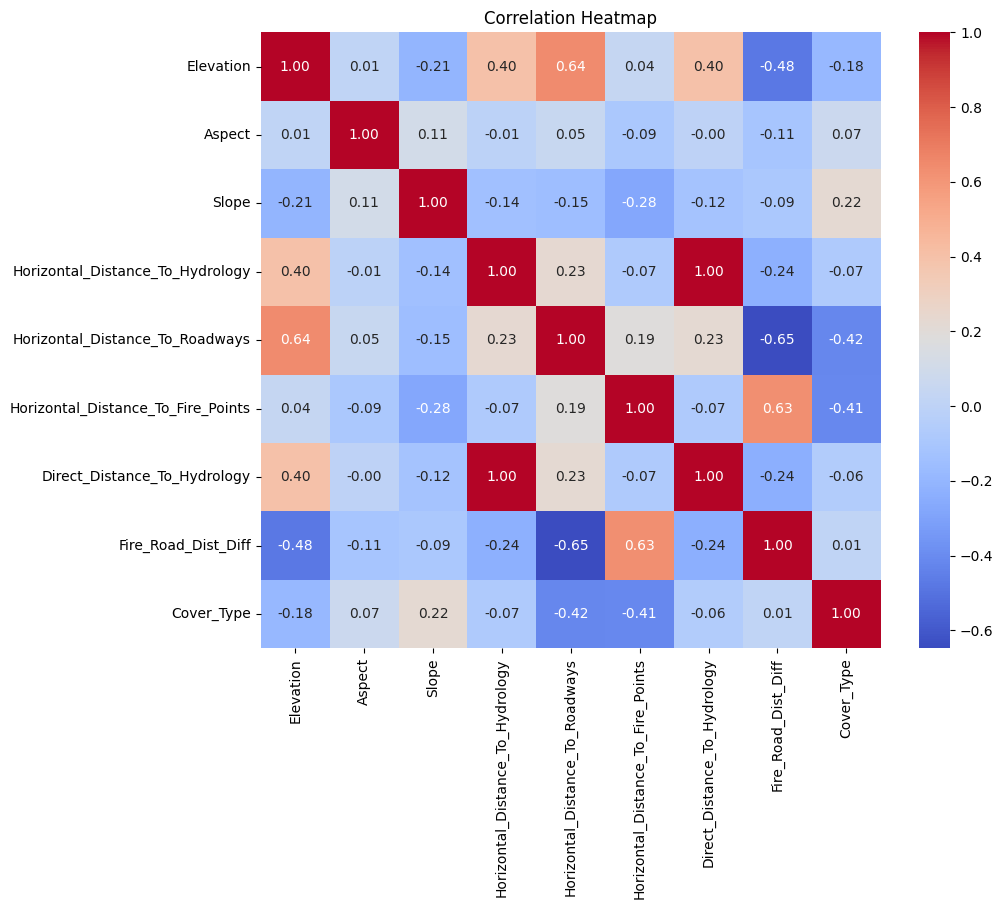

In [7]:
cols_to_check = continuous_features + ['Direct_Distance_To_Hydrology', 'Fire_Road_Dist_Diff', 'Cover_Type']
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[cols_to_check].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()